# Violence Detection - CNN Baseline Model
## Google Colab Training Notebook

**Model 1: Pure CNN (Baseline)**
- No CBAM, No LSTM, No Attention
- Simple CNN architecture
- Used for comparison with CNN+CBAM

**Dataset:** Real Life Violence Situations Dataset

**Framework:** TensorFlow / Keras

## Step 1: Check GPU

In [ ]:
import tensorflow as tf

print('TensorFlow Version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

# Enable GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('✓ GPU ready')
else:
    print('⚠ No GPU found - Go to Runtime > Change runtime type > GPU')

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ GPU ready


## Step 2: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✓ Google Drive mounted')

Mounted at /content/drive
✓ Google Drive mounted


## Step 3: Configuration
**⚠ Update DATASET_PATH to your Google Drive dataset location**

In [ ]:
import os

# ============================================================
# UPDATE THIS PATH TO YOUR DATASET LOCATION IN GOOGLE DRIVE
# ============================================================
DATASET_PATH = '/content/drive/MyDrive/Violence_Detection_Frames'  # <-- Change this!

# Configuration
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 20
SAVE_DIR    = '/content/drive/MyDrive/cnn_baseline_model'

os.makedirs(SAVE_DIR, exist_ok=True)

print('Configuration:')
print(f'  Dataset  : {DATASET_PATH}')
print(f'  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch    : {BATCH_SIZE}')
print(f'  Epochs   : {EPOCHS}')
print(f'  Save Dir : {SAVE_DIR}')

Configuration:
  Dataset  : /content/drive/MyDrive/Violence_Detection_Frames
  IMG_SIZE : 224x224
  Batch    : 32
  Epochs   : 20
  Save Dir : /content/drive/MyDrive/cnn_baseline_model


## Step 4: Copy Dataset to Local Storage (Faster Training)

In [ ]:
import shutil

LOCAL_PATH = '/content/dataset'

if os.path.exists(LOCAL_PATH):
    shutil.rmtree(LOCAL_PATH)

print('Copying dataset to local storage...')
shutil.copytree(DATASET_PATH, LOCAL_PATH)
print('✓ Dataset copied')

# Verify
violence_count     = len(os.listdir(os.path.join(LOCAL_PATH, 'Violence')))
nonviolence_count  = len(os.listdir(os.path.join(LOCAL_PATH, 'NonViolence')))

print(f'\nDataset:')
print(f'  Violence    : {violence_count} frames')
print(f'  NonViolence : {nonviolence_count} frames')
print(f'  Total       : {violence_count + nonviolence_count} frames')

Copying dataset to local storage...
✓ Dataset copied

Dataset:
  Violence    : 11988 frames
  NonViolence : 11964 frames
  Total       : 23952 frames


## Step 5: Data Generators

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training augmentation
train_datagen = ImageDataGenerator(
    rescale          = 1./255,
    rotation_range   = 20,
    width_shift_range= 0.2,
    height_shift_range=0.2,
    horizontal_flip  = True,
    zoom_range       = 0.2,
    validation_split = 0.2
)

# Validation (no augmentation)
val_datagen = ImageDataGenerator(
    rescale         = 1./255,
    validation_split= 0.2
)

train_generator = train_datagen.flow_from_directory(
    LOCAL_PATH,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    shuffle      = True
)

val_generator = val_datagen.flow_from_directory(
    LOCAL_PATH,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    shuffle      = False
)

print(f'\n✓ Training samples   : {train_generator.samples}')
print(f'✓ Validation samples : {val_generator.samples}')
print(f'✓ Classes            : {train_generator.class_indices}')

Found 19163 images belonging to 2 classes.
Found 4789 images belonging to 2 classes.

✓ Training samples   : 19163
✓ Validation samples : 4789
✓ Classes            : {'NonViolence': 0, 'Violence': 1}


## Step 6: Build CNN Model (Baseline - No CBAM)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

def build_cnn_model(img_size=224):
    """
    Pure CNN Model - No Attention Mechanism
    Used as baseline for comparison with CNN+CBAM
    """
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      input_shape=(img_size, img_size, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Classification Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')  # Violence / NonViolence
    ])

    return model

# Build
cnn_model = build_cnn_model(IMG_SIZE)

# Compile
cnn_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print('✓ CNN Model built')
print(f'  Total parameters: {cnn_model.count_params():,}')
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✓ CNN Model built
  Total parameters: 127,682


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,682 (498.76 KB)

 Trainable params: 127,234 (497.01 KB)

 Non-trainable params: 448 (1.75 KB)

## Step 7: Callbacks

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_path = os.path.join(SAVE_DIR, 'cnn_best.weights.h5')

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor        = 'val_accuracy',
        save_best_only = True,
        save_weights_only = True,
        mode           = 'max',
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

print('✓ Callbacks ready')

✓ Callbacks ready


## Step 8: Train CNN Model

In [ ]:
print('='*60)
print('Training CNN Baseline Model')
print('='*60)

history = cnn_model.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1
)

print('\n✓ Training Complete!')

Training CNN Baseline Model
Epoch 1/20
599/599 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.7024 - loss: 0.5724
Epoch 1: val_accuracy improved from None to 0.83358, saving model to /content/drive/MyDrive/cnn_baseline_model/cnn_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_baseline_model/cnn_best.weights.h5
599/599 ━━━━━━━━━━━━━━━━━━━━ 268s 431ms/step - accuracy: 0.7519 - loss: 0.5048 - val_accuracy: 0.8336 - val_loss: 0.3876 - learning_rate: 0.0010
Epoch 2/20
599/599 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.8171 - loss: 0.4064
Epoch 2: val_accuracy did not improve from 0.83358
599/599 ━━━━━━━━━━━━━━━━━━━━ 270s 451ms/step - accuracy: 0.8272 - loss: 0.3895 - val_accuracy: 0.6768 - val_loss: 0.7389 - learning_rate: 0.0010
Epoch 3/20
599/599 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.8544 - loss: 0.3386
Epoch 3: val_accuracy did not improve from 0.83358
599/599 ━━━━━━━━━━━━━━━━━━━━ 268s 448ms/step - accuracy: 0.8613 - loss: 0.3283 - val_acc

## Step 9: Plot Training Results

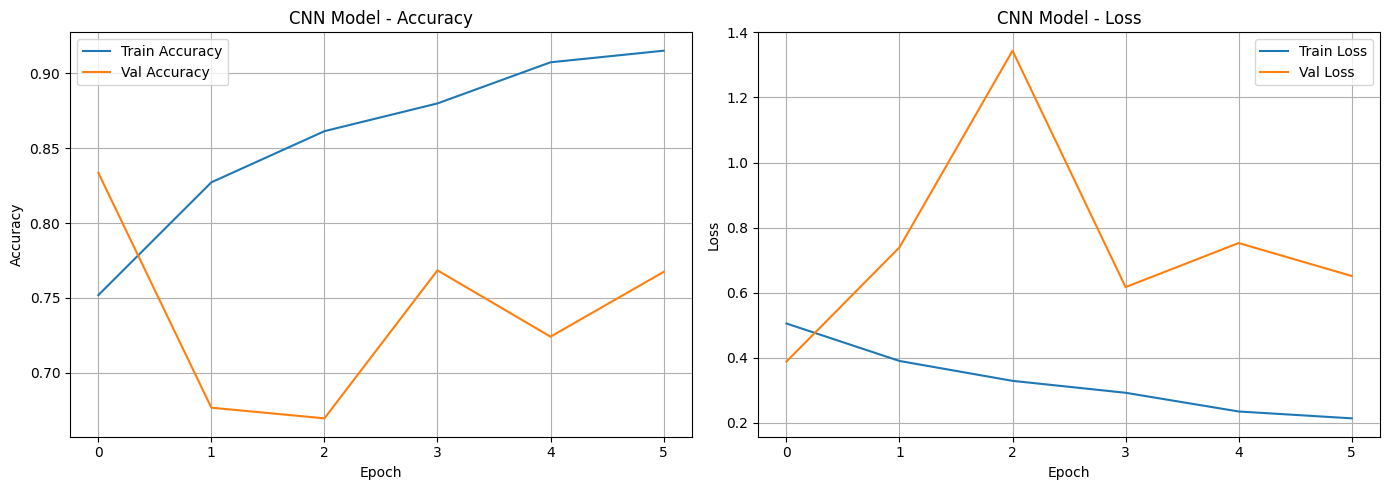


Best Validation Accuracy : 83.36%
Best Epoch               : 1


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cnn_training_history.png'), dpi=150)
plt.show()

best_acc   = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_acc) + 1

print(f'\nBest Validation Accuracy : {best_acc*100:.2f}%')
print(f'Best Epoch               : {best_epoch}')

## Step 10: Evaluate on Validation Set

150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step

Classification Report:
              precision    recall  f1-score   support

 NonViolence       0.91      0.74      0.82      2392
    Violence       0.78      0.93      0.85      2397

    accuracy                           0.83      4789
   macro avg       0.85      0.83      0.83      4789
weighted avg       0.85      0.83      0.83      4789



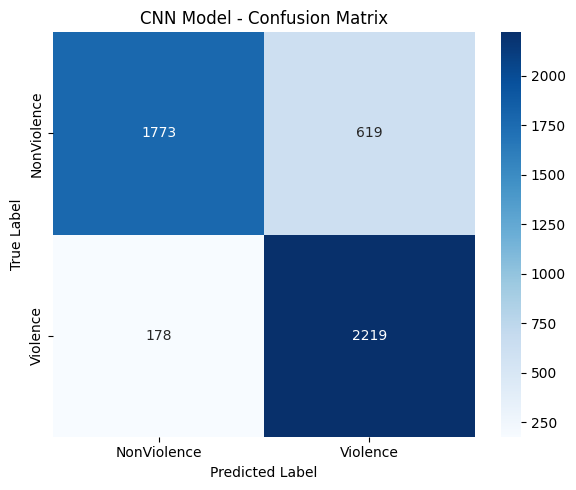

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
val_generator.reset()
predictions  = cnn_model.predict(val_generator, verbose=1)
y_pred       = np.argmax(predictions, axis=1)
y_true       = val_generator.classes
class_names  = list(val_generator.class_indices.keys())

# Classification Report
print('\nClassification Report:')
print('='*50)
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cnn_confusion_matrix.png'), dpi=150)
plt.show()

## Step 11: Save Model Info

In [ ]:
import json
from datetime import datetime
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print('='*50)
print('CNN Model - Final Performance Metrics')
print('='*50)
print(f'Accuracy  : {accuracy*100:.2f}%')
print(f'Precision : {precision*100:.2f}%')
print(f'Recall    : {recall*100:.2f}%')
print(f'F1-Score  : {f1*100:.2f}%')
print('='*50)

# Save info
model_info = {
    'model'        : 'CNN (Baseline)',
    'img_size'     : IMG_SIZE,
    'num_classes'  : 2,
    'parameters'   : int(cnn_model.count_params()),
    'accuracy'     : float(accuracy),
    'precision'    : float(precision),
    'recall'       : float(recall),
    'f1_score'     : float(f1),
    'best_epoch'   : int(best_epoch),
    'trained_date' : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'architecture' : 'CNN only - No CBAM'
}

with open(os.path.join(SAVE_DIR, 'cnn_model_info.json'), 'w') as f:
    json.dump(model_info, f, indent=2)

print('\n✓ Model info saved')

CNN Model - Final Performance Metrics
Accuracy  : 83.36%
Precision : 84.53%
Recall    : 83.36%
F1-Score  : 83.21%

✓ Model info saved


## Step 12: Download Model Files

In [ ]:
from google.colab import files

# Download weights
files.download(checkpoint_path)
files.download(os.path.join(SAVE_DIR, 'cnn_model_info.json'))
files.download(os.path.join(SAVE_DIR, 'cnn_training_history.png'))
files.download(os.path.join(SAVE_DIR, 'cnn_confusion_matrix.png'))

print('\n✓ All files downloaded!')
print('\nComparison Summary:')
print('='*50)
print(f'CNN Baseline  Accuracy : {accuracy*100:.2f}%')
print(f'CNN + CBAM    Accuracy : 96.70%  (your existing model)')
print('='*50)
print('CNN+CBAM outperforms CNN baseline due to attention mechanism')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ All files downloaded!

Comparison Summary:
CNN Baseline  Accuracy : 83.36%
CNN + CBAM    Accuracy : 96.70%  (your existing model)
CNN+CBAM outperforms CNN baseline due to attention mechanism
